# Naive Bayes Híbrido — Dados Contínuos e Discretos

Este notebook implementa manualmente um classificador **Naive Bayes híbrido**:
- **Gaussiano** → para atributos contínuos (usa média e desvio padrão)
- **Categórico** → para atributos discretos (usa frequência com suavização de Laplace)

Dataset utilizado: **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`).

## 1. Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento e Preparação do Dataset

O dataset **Breast Cancer Wisconsin** possui 30 atributos contínuos.
Para atender ao requisito de ter dados **contínuos e discretos**, algumas colunas
são discretizadas em faixas numéricas usando `pd.cut`.

| Tipo | Colunas (índices) | Descrição |
|---|---|---|
| **Contínuo** | 0 a 22 | Medidas originais das células |
| **Discreto** | 23 a 29 | Medidas originais discretizadas em 3 faixas: 0, 1, 2 |

In [2]:
# Carrega o dataset
data = load_breast_cancer()
X_raw = data.data
y = data.target

print("Atributos originais:", data.feature_names)
print(f"\nShape original: {X_raw.shape}")
print(f"Classes: {data.target_names}")

Atributos originais: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Shape original: (569, 30)
Classes: ['malignant' 'benign']


In [3]:
# Índices das colunas que serão mantidas contínuas
idx_continuo = list(range(23))

# Índices das colunas que serão discretizadas (últimas 7 colunas)
idx_para_discretizar = list(range(23, 30))

# Discretiza as colunas escolhidas em 3 faixas: 0 (baixo), 1 (médio), 2 (alto)
X_discreto = np.zeros((X_raw.shape[0], len(idx_para_discretizar)), dtype=int)
for k, j in enumerate(idx_para_discretizar):
    X_discreto[:, k] = pd.cut(X_raw[:, j], bins=3, labels=[0, 1, 2]).astype(int)

# Monta o dataset final: colunas contínuas + colunas discretizadas
X = np.column_stack([X_raw[:, idx_continuo], X_discreto])

# Atualiza os índices no dataset final
idx_continuo = list(range(23))
idx_discreto = list(range(23, 30))

print(f"Shape final do dataset: {X.shape}")
print(f"Colunas contínuas : índices {idx_continuo[0]} a {idx_continuo[-1]}")
print(f"Colunas discretas : índices {idx_discreto[0]} a {idx_discreto[-1]}")
print(f"\nExemplo — primeiros valores discretizados (0=baixo, 1=médio, 2=alto):")
print(X[:5, 23:])

Shape final do dataset: (569, 30)
Colunas contínuas : índices 0 a 22
Colunas discretas : índices 23 a 29

Exemplo — primeiros valores discretizados (0=baixo, 1=médio, 2=alto):
[[1. 1. 1. 1. 2. 1. 1.]
 [1. 1. 0. 0. 1. 0. 0.]
 [1. 1. 1. 1. 2. 1. 0.]
 [0. 2. 2. 1. 2. 2. 2.]
 [1. 1. 0. 0. 1. 0. 0.]]


## 3. Implementação do Naive Bayes Híbrido

A regra de decisão é baseada no **Teorema de Bayes**:

$$P(C|x) \propto P(C) \cdot \prod_{j} P(x_j | C)$$

- **Contínuo** → Distribuição Gaussiana:
$$P(x_j|C) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x_j-\mu)^2}{2\sigma^2}\right)$$

- **Discreto** → Frequência com suavização de Laplace:
$$P(x_j|C) = \frac{\text{count}(x_j, C) + 1}{n_C + |V_j|}$$

In [4]:
class naiveBayes:
    """
    Naive Bayes Híbrido:
      - Gaussiano para atributos contínuos
      - Frequência (com Laplace) para atributos discretos
    """

    def __init__(self, idx_continuo, idx_discreto):
        self.idx_continuo  = idx_continuo
        self.idx_discreto  = idx_discreto
        self.classes       = None
        self.prob_classe   = []   # P(C)
        self.media         = []   # médias gaussianas por classe
        self.std           = []   # desvios gaussianos por classe
        self.freq_discreta = []   # tabelas de frequência por classe
        self.valores_disc  = []   # valores únicos por coluna discreta

    def fit(self, X, y):
        self.classes = np.unique(y)

        # Valores únicos de cada coluna discreta (necessário para Laplace)
        self.valores_disc = [np.unique(X[:, j]) for j in self.idx_discreto]

        for c in self.classes:
            dados_c = X[y == c]

            # P(C) — probabilidade a priori
            self.prob_classe.append(len(dados_c) / len(X))

            # Parâmetros gaussianos
            self.media.append(np.mean(dados_c[:, self.idx_continuo], axis=0))
            self.std.append(np.std(dados_c[:, self.idx_continuo], axis=0))

            # Frequências discretas com suavização de Laplace
            freq_c = {}
            for k, j in enumerate(self.idx_discreto):
                col = dados_c[:, j]
                v   = len(self.valores_disc[k])
                freq_c[j] = {
                    val: (np.sum(col == val) + 1) / (len(col) + v)
                    for val in self.valores_disc[k]
                }
            self.freq_discreta.append(freq_c)

    def gauss(self, media, std, x):
        """Densidade gaussiana — mesma fórmula do notebook do professor."""
        return 1 / np.sqrt(2 * np.pi * std**2) * np.e ** (-((x - media)**2) / (2 * std**2))

    def predict(self, X):
        preds = []
        for x in X:
            log_probs = []
            for i, c in enumerate(self.classes):
                # log P(C)
                log_p = np.log(self.prob_classe[i])

                # log P(x_cont | C) — Gaussiano
                pg = self.gauss(self.media[i], self.std[i], x[self.idx_continuo])
                pg = np.clip(pg, 1e-300, None)   # evita log(0)
                log_p += np.sum(np.log(pg))

                # log P(x_disc | C) — Frequência
                for k, j in enumerate(self.idx_discreto):
                    val   = x[j]
                    p_d   = self.freq_discreta[i][j].get(
                                val, 1 / (len(self.freq_discreta[i][j]) + len(self.valores_disc[k]))
                            )
                    log_p += np.log(p_d)

                log_probs.append(log_p)

            preds.append(self.classes[np.argmax(log_probs)])
        return np.array(preds)

## 4. Treinamento e Avaliação

In [5]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino : {X_treino.shape[0]} amostras")
print(f"Teste  : {X_teste.shape[0]} amostras")

Treino : 398 amostras
Teste  : 171 amostras


In [6]:
nb = naiveBayes(idx_continuo=idx_continuo, idx_discreto=idx_discreto)
nb.fit(X_treino, y_treino)
predicoes = nb.predict(X_teste)

acc = accuracy_score(y_teste, predicoes)
print(f"Acurácia no conjunto de teste: {acc*100:.2f}%")

Acurácia no conjunto de teste: 95.32%


## 5. Matriz de Confusão

In [7]:
cm = confusion_matrix(y_teste, predicoes)
print("Matriz de Confusão:")
print(cm)

Matriz de Confusão:
[[ 57   7]
 [  1 106]]


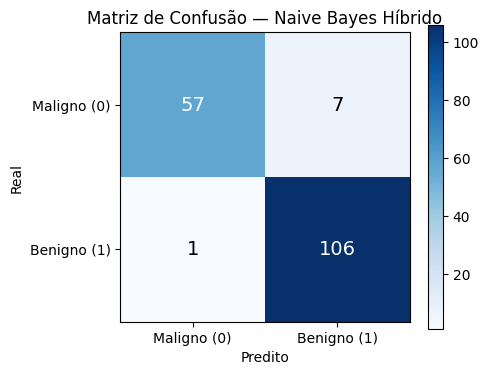

In [8]:
labels_classe = ['Maligno (0)', 'Benigno (1)']

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels_classe); ax.set_yticklabels(labels_classe)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Naive Bayes Híbrido')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Visualização dos Parâmetros Aprendidos
### 6.1 Médias dos atributos contínuos por classe (primeiros 6)

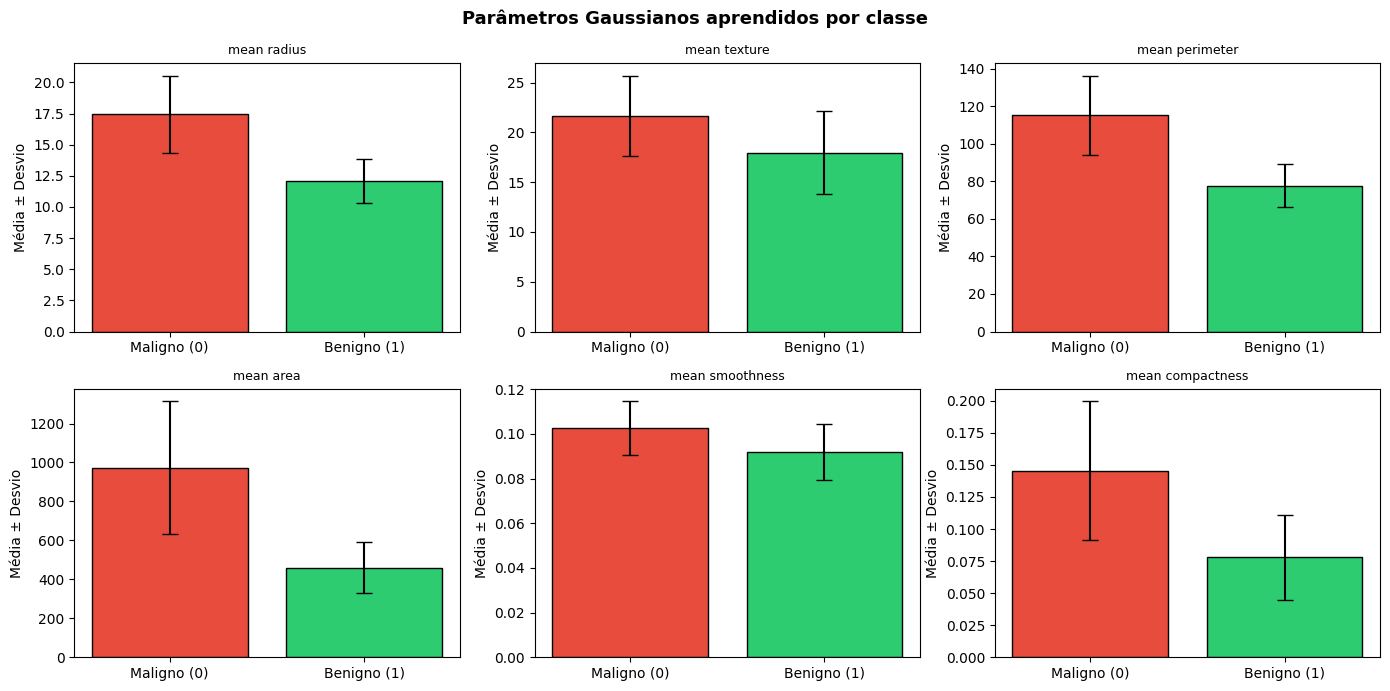

In [9]:
nomes_cont = list(data.feature_names[:6])
cores = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for k, ax in enumerate(axes):
    medias = [nb.media[i][k] for i in range(2)]
    stds   = [nb.std[i][k]   for i in range(2)]
    ax.bar(labels_classe, medias, color=cores, yerr=stds, capsize=6, edgecolor='black')
    ax.set_title(nomes_cont[k], fontsize=9)
    ax.set_ylabel('Média ± Desvio')

plt.suptitle('Parâmetros Gaussianos aprendidos por classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Probabilidades dos atributos discretos por classe

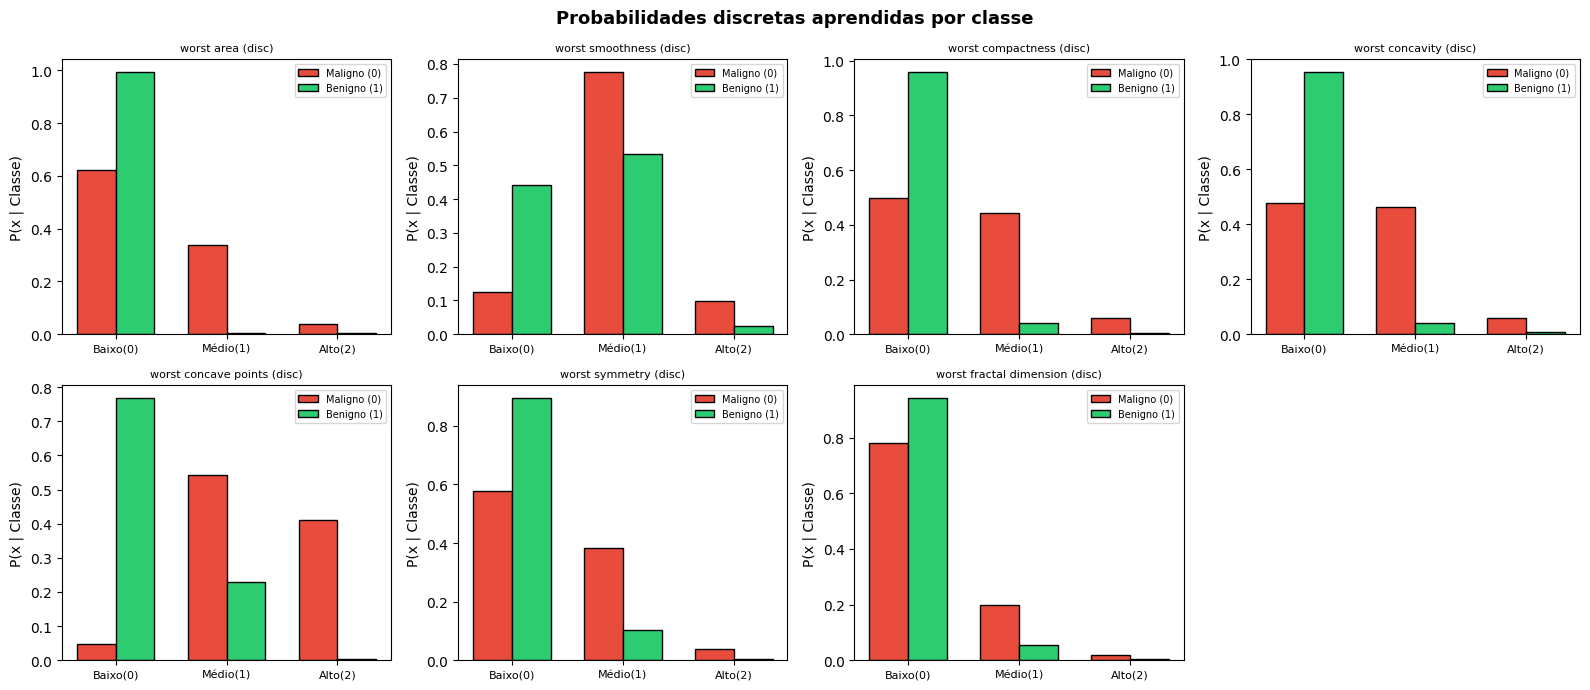

In [10]:
nomes_disc = [f"{data.feature_names[j]} (disc)" for j in idx_para_discretizar]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for k, (j, ax) in enumerate(zip(idx_discreto, axes)):
    vals  = nb.valores_disc[k]
    x_pos = np.arange(len(vals))
    width = 0.35
    for i, (lbl, cor) in enumerate(zip(labels_classe, cores)):
        probs = [nb.freq_discreta[i][j][v] for v in vals]
        ax.bar(x_pos + i * width, probs, width, label=lbl, color=cor, edgecolor='black')
    ax.set_xticks(x_pos + width / 2)
    ax.set_xticklabels(['Baixo(0)', 'Médio(1)', 'Alto(2)'], fontsize=8)
    ax.set_title(nomes_disc[k], fontsize=8)
    ax.set_ylabel('P(x | Classe)')
    ax.legend(fontsize=7)

# Remove subplot extra
for ax in axes[len(idx_discreto):]:
    ax.set_visible(False)

plt.suptitle('Probabilidades discretas aprendidas por classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()